# Phase 8: Model Interpretability & Explainability

Produces global and local explanations for all three layers of the routing system:
the Application Model, the Behavioral Model, and the routing decision itself.

**Method:** SHAP TreeExplainer — model-specific, exact (not approximate) for tree ensembles.

**Deliverables:**
1. Global SHAP — top feature drivers for each model
2. Model comparison — which signals matter in Application vs. Behavioral
3. Local SHAP — waterfall explanations for low / medium / high risk clients
4. Routing rationale — plain-language explanation of dispatch decision per client
5. Feature stability — SHAP mean |value| across client segments (UF, segmento)
6. Model cards — assumptions, limitations, known failure modes

In [1]:
import sys
import json
import warnings
from pathlib import Path
from datetime import datetime

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
import seaborn as sns
import joblib
import shap

from sklearn.inspection import permutation_importance
from sklearn.metrics import roc_auc_score

warnings.filterwarnings('ignore')
shap.initjs()

RANDOM_STATE = 42
np.random.seed(RANDOM_STATE)

ROOT       = Path('..').resolve()
DATA_DIR   = ROOT / 'data'
MODELS_DIR = ROOT / 'models'
sys.path.insert(0, str(ROOT / 'src'))

from router import ModelRouter, engineer_features

# How many clients to use for global SHAP (speed vs. coverage)
SHAP_SAMPLE_APP   = 500   # from 3,000
SHAP_SAMPLE_BEHAV = 664   # use all behavioral clients

print('Setup complete. SHAP version:', shap.__version__)

Setup complete. SHAP version: 0.49.1


## 1. Load Models and Data

In [2]:
with warnings.catch_warnings():
    warnings.simplefilter('ignore')
    app_model   = joblib.load(sorted(MODELS_DIR.glob('04_application_best_tuned_xgboost_*.joblib'))[-1])
    behav_model = joblib.load(sorted(MODELS_DIR.glob('05_behavioral_best_*.joblib'))[-1])
    ml_router   = joblib.load(sorted(MODELS_DIR.glob('06_ml_router_decision_tree_*.joblib'))[-1])

router = ModelRouter(
    app_model=app_model, behav_model=behav_model,
    threshold_a=0.5, threshold_b=0.6, ml_router=ml_router,
)

df_raw = pd.read_csv(sorted(DATA_DIR.glob('03_behavioral_combined_*.csv'))[-1], low_memory=False)
df     = engineer_features(df_raw)
y_all  = df_raw['inadimplente'].astype(int)

has_behavioral = df['orders_count'].notna()
df_behav = df[has_behavioral].copy()
y_behav  = y_all[has_behavioral]

# Router predictions for all clients
with warnings.catch_warnings():
    warnings.simplefilter('ignore')
    route_result = router.predict(df, use_ml_router=False)
    p_app_all = pd.Series(app_model.predict_proba(df)[:, 1], index=df.index)
    p_behav_sub = pd.Series(
        behav_model.predict_proba(df_behav)[:, 1], index=df_behav.index
    )

print(f'Loaded: {len(df):,} total clients, {has_behavioral.sum()} with behavioral data')
print('Models:', app_model.named_steps['clf'].__class__.__name__,
      '/', behav_model.named_steps['clf'].__class__.__name__)

Loaded: 3,000 total clients, 664 with behavioral data
Models: XGBClassifier / RandomForestClassifier


## 2. Helper: Feature Names and Data Transformation

In [3]:
def get_feature_names(pipeline):
    """Extract feature names from a sklearn Pipeline with a ColumnTransformer preprocessor."""
    pre   = pipeline.named_steps['pre']
    names = []
    for tname, trans, cols in pre.transformers_:
        if tname == 'remainder':
            continue
        if hasattr(trans, 'get_feature_names_out'):
            names.extend(trans.get_feature_names_out(cols).tolist())
        else:
            names.extend(cols)
    return names


def transform(pipeline, X):
    """Apply only the preprocessor step of a pipeline."""
    with warnings.catch_warnings():
        warnings.simplefilter('ignore')
        return pipeline.named_steps['pre'].transform(X)


app_feature_names   = get_feature_names(app_model)
behav_feature_names = get_feature_names(behav_model)

# Sample indices for global SHAP (app model)
sample_idx = np.random.choice(len(df), size=SHAP_SAMPLE_APP, replace=False)
X_app_sample   = transform(app_model,   df.iloc[sample_idx])
X_behav_all    = transform(behav_model, df_behav)
y_app_sample   = y_all.iloc[sample_idx].values

print(f'App model features   : {len(app_feature_names)}')
print(f'Behav model features : {len(behav_feature_names)}')
print(f'App SHAP sample size : {X_app_sample.shape[0]}')
print(f'Behav SHAP size      : {X_behav_all.shape[0]}')

App model features   : 76
Behav model features : 83
App SHAP sample size : 500
Behav SHAP size      : 664


## 3. Global SHAP — Application Model

SHAP TreeExplainer for XGBoost. Positive SHAP values push toward *default* (inadimplente=1).

In [4]:
explainer_app = shap.TreeExplainer(app_model.named_steps['clf'])
shap_vals_app = explainer_app.shap_values(X_app_sample)  # shape (n, 76)

# Mean |SHAP| per feature
mean_abs_app = pd.Series(
    np.abs(shap_vals_app).mean(axis=0),
    index=app_feature_names
).sort_values(ascending=False)

print('Top 15 features — Application Model (mean |SHAP|):')
print(mean_abs_app.head(15).round(4).to_string())

Top 15 features — Application Model (mean |SHAP|):
idade_cnpj_mid                                             0.5533
serasa_socio_tem_negativacao                               0.3700
serasa_n_setores                                           0.1934
segmento_cliente_Segmento 16                               0.1411
fonte_cliente_Fonte 5                                      0.1378
capital_social_mid                                         0.1021
natureza_juridica_213-5 - Empresário (Individual)          0.0913
natureza_juridica_206-2 - Sociedade Empresária Limitada    0.0558
segmento_cliente_Segmento 18                               0.0530
serasa_contagem_negativacoes                               0.0500
fonte_cliente_Fonte 2                                      0.0454
cnae_divisao_77                                            0.0163
segmento_cliente_Segmento 5                                0.0161
segmento_cliente_Segmento 20                               0.0158
segmento_cliente_Segmento

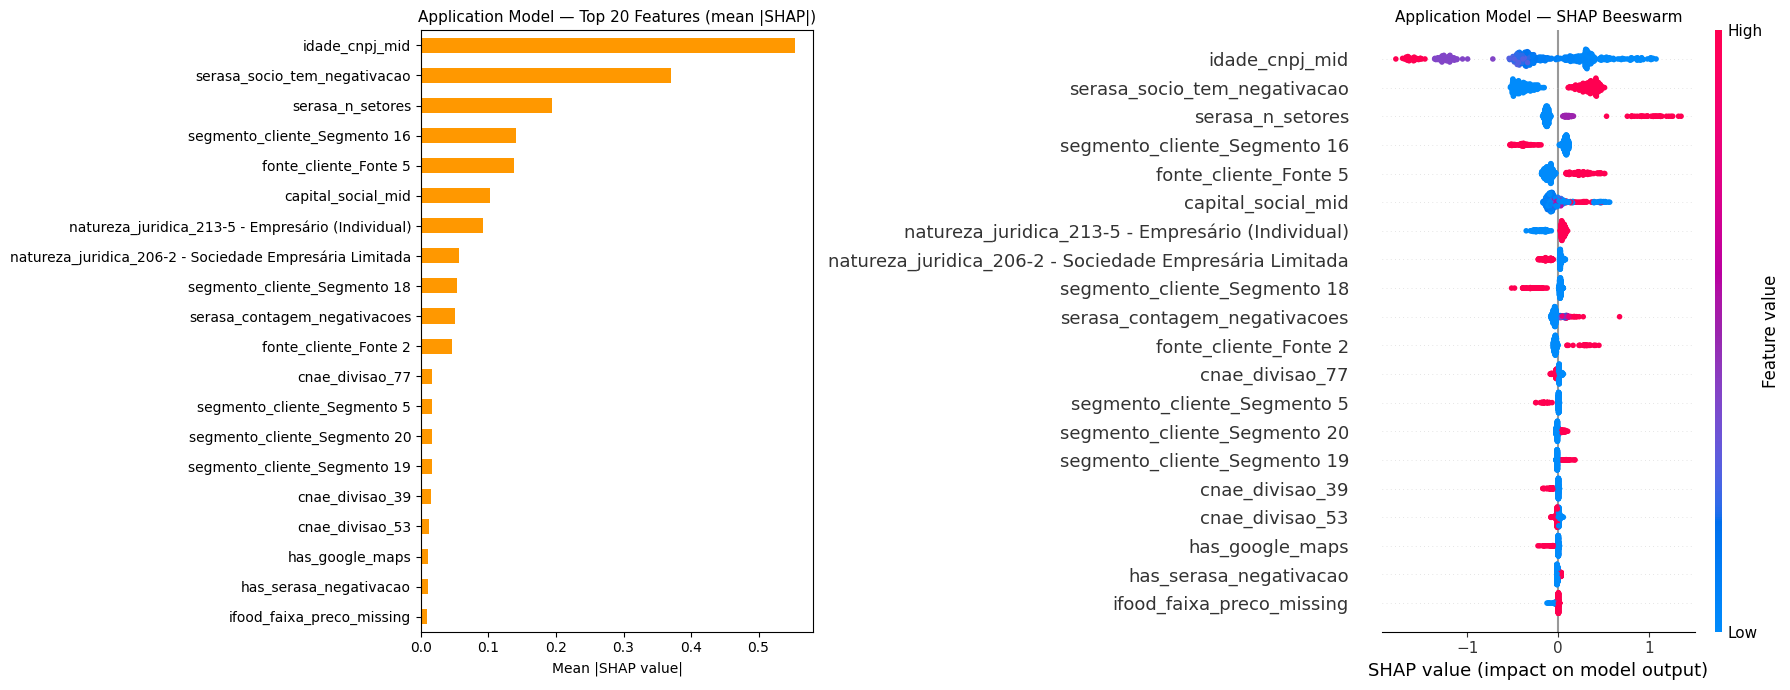

Saved application model SHAP global plot.


In [5]:
fig, axes = plt.subplots(1, 2, figsize=(18, 7))

# Bar plot — mean |SHAP|
ax = axes[0]
top20 = mean_abs_app.head(20)
top20[::-1].plot.barh(ax=ax, color='#FF9800')
ax.set_title('Application Model — Top 20 Features (mean |SHAP|)', fontsize=11)
ax.set_xlabel('Mean |SHAP value|')

# Beeswarm plot
ax = axes[1]
top20_idx = [app_feature_names.index(f) for f in top20.index]
shap.summary_plot(
    shap_vals_app[:, top20_idx],
    X_app_sample[:, top20_idx],
    feature_names=top20.index.tolist(),
    show=False, plot_size=None, max_display=20,
)
plt.sca(ax)
ax.set_title('Application Model — SHAP Beeswarm', fontsize=11)

fig.tight_layout()
plt.savefig(DATA_DIR / '08_shap_app_global.png', dpi=150, bbox_inches='tight')
plt.show()
print('Saved application model SHAP global plot.')

## 4. Global SHAP — Behavioral Model

SHAP TreeExplainer for Random Forest. For multi-output RF, `shap_values` returns
a list `[shap_class0, shap_class1]` — we use class 1 (default).

In [6]:
explainer_behav = shap.TreeExplainer(behav_model.named_steps['clf'])
shap_vals_behav_raw = explainer_behav.shap_values(X_behav_all)

# RF returns (n, features, 2) or list of 2 arrays; take class-1 slice
if isinstance(shap_vals_behav_raw, list):
    shap_vals_behav = shap_vals_behav_raw[1]          # list[1] = class 1
elif shap_vals_behav_raw.ndim == 3:
    shap_vals_behav = shap_vals_behav_raw[:, :, 1]   # (n, features, 2) → (n, features)
else:
    shap_vals_behav = shap_vals_behav_raw

mean_abs_behav = pd.Series(
    np.abs(shap_vals_behav).mean(axis=0),
    index=behav_feature_names
).sort_values(ascending=False)

print('Top 15 features — Behavioral Model (mean |SHAP|):')
print(mean_abs_behav.head(15).round(4).to_string())

Top 15 features — Behavioral Model (mean |SHAP|):
idade_cnpj_mid                  0.0384
delay_mean                      0.0375
orders_per_month                0.0369
delay_max                       0.0333
pct_orders_delayed              0.0259
delay_spike_ratio               0.0258
recency_days                    0.0257
capital_social_mid              0.0134
serasa_socio_tem_negativacao    0.0118
segmento_cliente_Segmento 20    0.0101
segmento_cliente_Segmento 15    0.0100
ifood_faixa_preco_missing       0.0093
valor_max                       0.0090
valor_mean                      0.0086
log_valor_mean                  0.0080


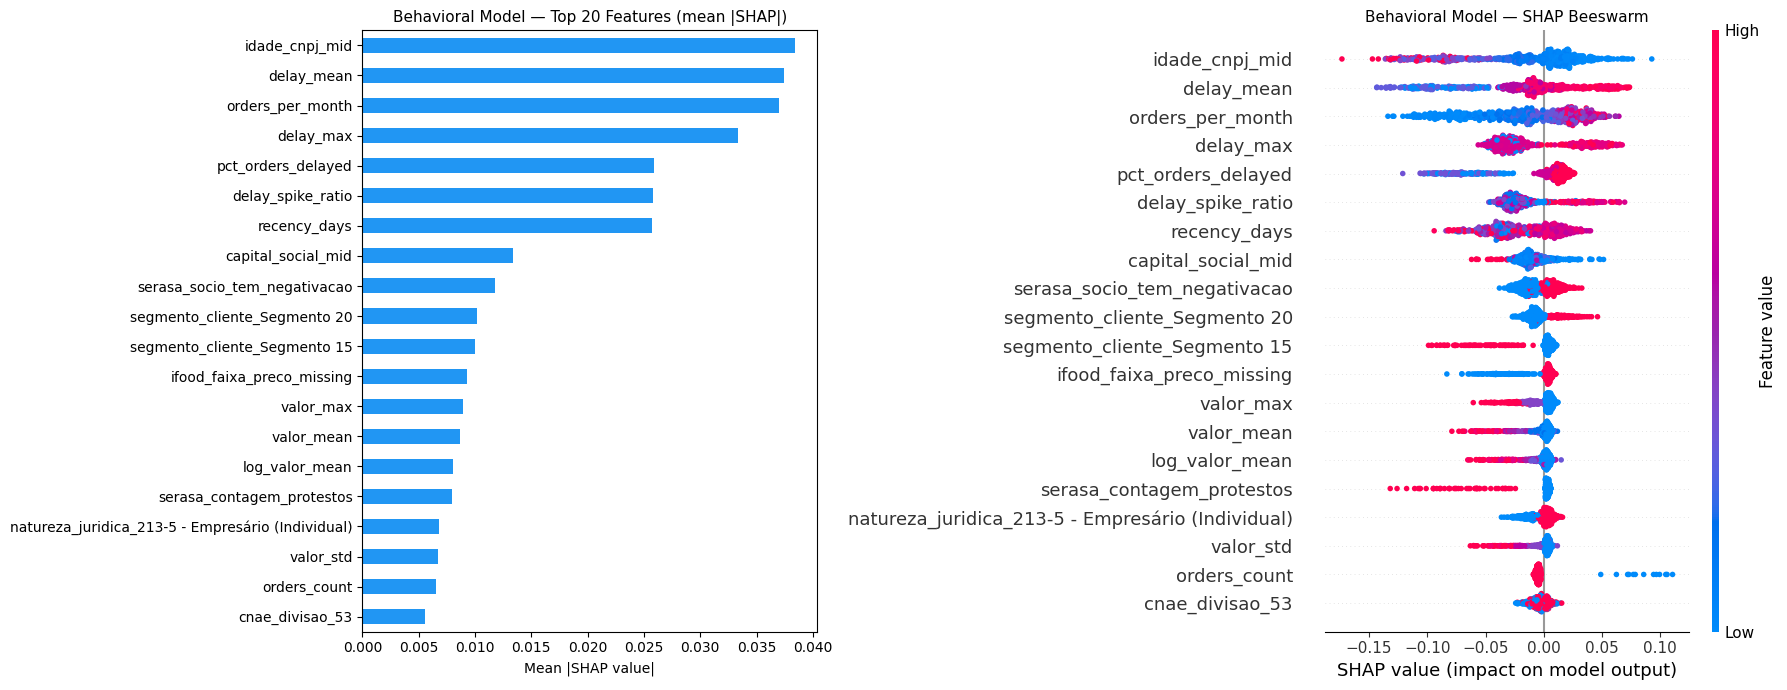

Saved behavioral model SHAP global plot.


In [7]:
fig, axes = plt.subplots(1, 2, figsize=(18, 7))

ax = axes[0]
top20_b = mean_abs_behav.head(20)
top20_b[::-1].plot.barh(ax=ax, color='#2196F3')
ax.set_title('Behavioral Model — Top 20 Features (mean |SHAP|)', fontsize=11)
ax.set_xlabel('Mean |SHAP value|')

ax = axes[1]
top20_b_idx = [behav_feature_names.index(f) for f in top20_b.index]
shap.summary_plot(
    shap_vals_behav[:, top20_b_idx],
    X_behav_all[:, top20_b_idx],
    feature_names=top20_b.index.tolist(),
    show=False, plot_size=None, max_display=20,
)
plt.sca(ax)
ax.set_title('Behavioral Model — SHAP Beeswarm', fontsize=11)

fig.tight_layout()
plt.savefig(DATA_DIR / '08_shap_behav_global.png', dpi=150, bbox_inches='tight')
plt.show()
print('Saved behavioral model SHAP global plot.')

## 5. Model Comparison — Top Feature Drivers

Side-by-side: which features drive Application Model vs. Behavioral Model,
and what is the share of behavioral vs. application signal in the Behavioral Model.

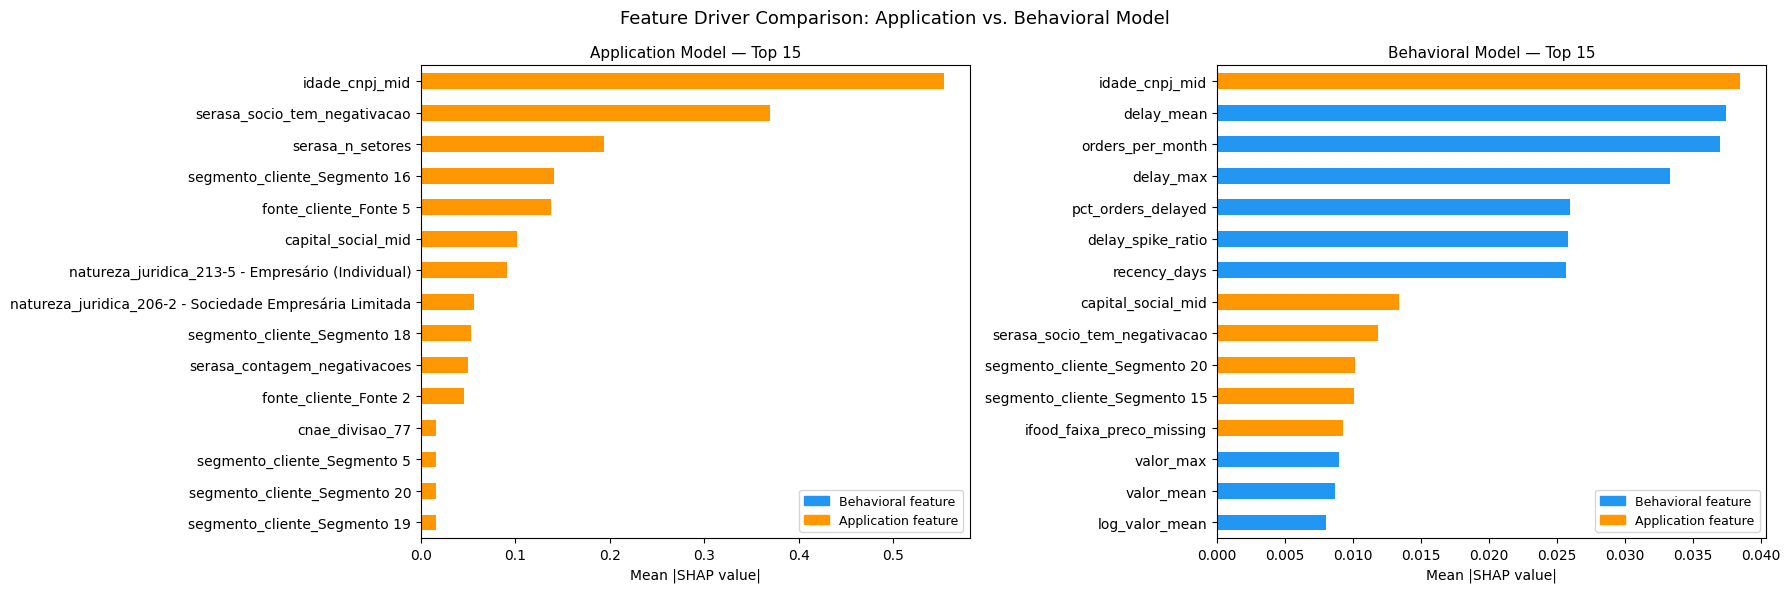

Behavioral signal share in Behavioral Model: 59.1%
Application signal share in Behavioral Model: 40.9%
Saved model comparison plot.


In [8]:
BEHAVIORAL_PREFIXES = (
    'orders_count', 'valor_', 'log_valor', 'delay_', 'pct_orders',
    'recency', 'orders_per_month', 'has_any_delay', 'delay_spike',
)

def feature_type(name):
    return 'Behavioral' if any(name.startswith(p) for p in BEHAVIORAL_PREFIXES) else 'Application'


# Top-15 from each model
top15_app   = mean_abs_app.head(15)
top15_behav = mean_abs_behav.head(15)

fig, axes = plt.subplots(1, 2, figsize=(18, 6))

for ax, top15, title in [
    (axes[0], top15_app,   'Application Model — Top 15'),
    (axes[1], top15_behav, 'Behavioral Model — Top 15'),
]:
    colors = ['#2196F3' if feature_type(f) == 'Behavioral' else '#FF9800'
              for f in top15.index]
    top15[::-1].plot.barh(ax=ax, color=colors[::-1])
    ax.set_title(title, fontsize=11)
    ax.set_xlabel('Mean |SHAP value|')
    legend_elems = [
        mpatches.Patch(color='#2196F3', label='Behavioral feature'),
        mpatches.Patch(color='#FF9800', label='Application feature'),
    ]
    ax.legend(handles=legend_elems, fontsize=9, loc='lower right')

fig.suptitle('Feature Driver Comparison: Application vs. Behavioral Model', fontsize=13)
fig.tight_layout()
plt.savefig(DATA_DIR / '08_shap_model_comparison.png', dpi=150)
plt.show()

# Behavioral signal share in Behavioral Model
behav_importance = mean_abs_behav[mean_abs_behav.index.map(
    lambda f: feature_type(f) == 'Behavioral'
)].sum()
total_importance = mean_abs_behav.sum()
print(f'Behavioral signal share in Behavioral Model: {behav_importance/total_importance:.1%}')
print(f'Application signal share in Behavioral Model: {1 - behav_importance/total_importance:.1%}')
print('Saved model comparison plot.')

## 6. Local SHAP — Representative Clients

Select one client per risk tier (Low < 15%, Medium 15–30%, High > 30%)
and explain the prediction with a SHAP waterfall plot.

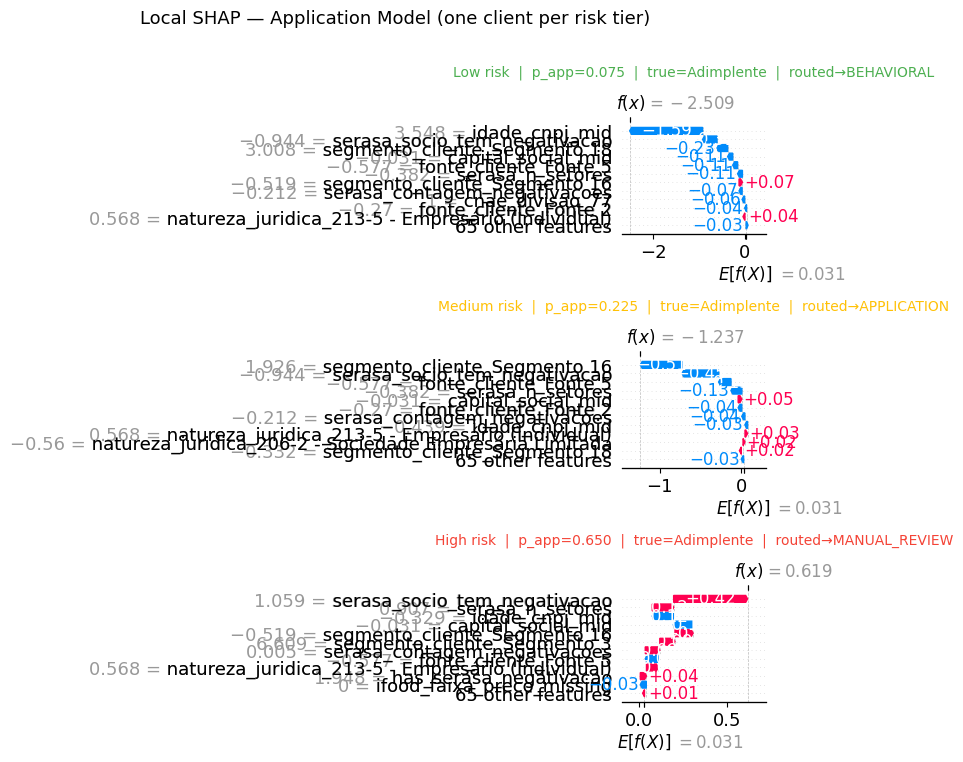

Saved local SHAP plot (Application Model).


In [9]:
def select_representative(probs, y, label, target_range):
    """Pick the index closest to the midpoint of target_range with correct label."""
    lo, hi  = target_range
    mid     = (lo + hi) / 2
    mask    = (probs >= lo) & (probs < hi)
    if mask.sum() == 0:
        mask = (probs >= lo) & (probs <= hi)
    candidates = probs[mask]
    idx = (candidates - mid).abs().idxmin()
    return idx


tiers_def = [
    ('Low risk',    (0.00, 0.15), '#4CAF50'),
    ('Medium risk', (0.15, 0.30), '#FFC107'),
    ('High risk',   (0.30, 1.00), '#F44336'),
]

fig, axes = plt.subplots(3, 1, figsize=(14, 14))

local_clients = []
for ax, (tier_name, range_, color) in zip(axes, tiers_def):
    idx = select_representative(p_app_all, y_all, tier_name, range_)
    row = df.loc[[idx]]
    X_row = transform(app_model, row)
    sv_row = explainer_app.shap_values(X_row)[0]  # shape (76,)

    shap_obj = shap.Explanation(
        values=sv_row,
        base_values=explainer_app.expected_value,
        data=X_row[0],
        feature_names=app_feature_names,
    )

    plt.sca(ax)
    shap.waterfall_plot(shap_obj, max_display=12, show=False)
    p_val  = float(p_app_all[idx])
    true_l = 'Inadimplente' if y_all[idx] else 'Adimplente'
    tier_r = route_result.loc[idx, 'tier']
    ax.set_title(
        f'{tier_name}  |  p_app={p_val:.3f}  |  true={true_l}  |  routed→{tier_r}',
        fontsize=10, color=color, pad=12
    )

    local_clients.append({
        'tier': tier_name, 'idx': idx,
        'p_app': round(p_val, 4),
        'true_label': true_l,
        'routing_tier': tier_r,
        'score_A': round(float(route_result.loc[idx, 'score_A']), 4),
        'score_B': round(float(route_result.loc[idx, 'score_B']), 4),
    })

fig.suptitle('Local SHAP — Application Model (one client per risk tier)', fontsize=13, y=1.01)
fig.tight_layout()
plt.savefig(DATA_DIR / '08_shap_app_local.png', dpi=150, bbox_inches='tight')
plt.show()
print('Saved local SHAP plot (Application Model).')

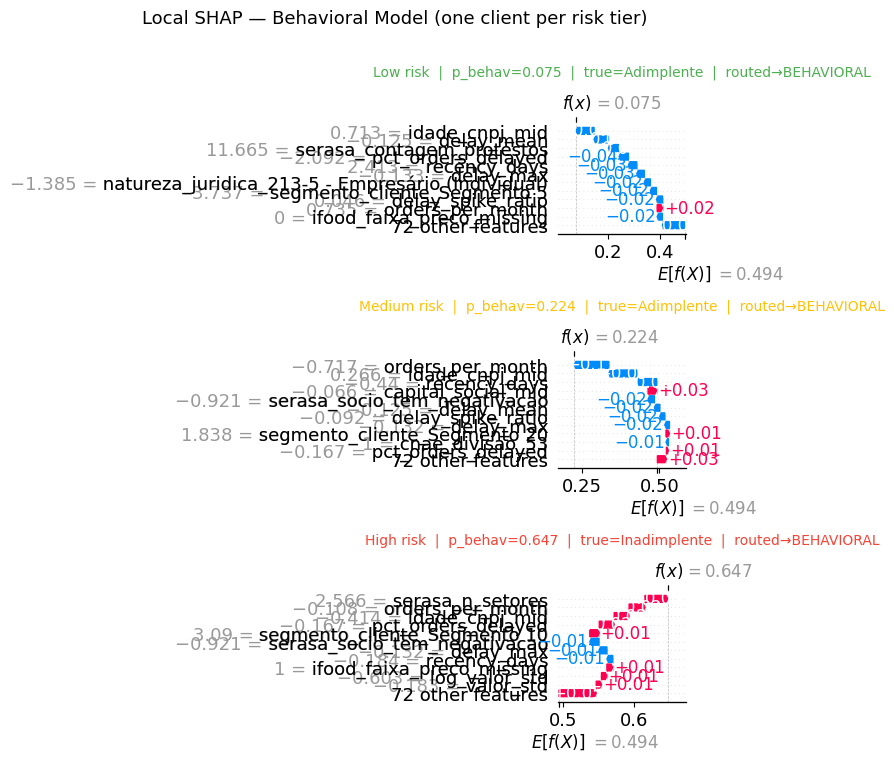

Saved local SHAP plot (Behavioral Model).


In [10]:
# Local SHAP for Behavioral Model — pick one behavioral client per risk tier
fig, axes = plt.subplots(3, 1, figsize=(14, 14))

for ax, (tier_name, range_, color) in zip(axes, tiers_def):
    idx = select_representative(p_behav_sub, y_behav, tier_name, range_)
    row = df_behav.loc[[idx]]
    X_row = transform(behav_model, row)

    sv_row_raw = explainer_behav.shap_values(X_row)
    if isinstance(sv_row_raw, list):
        sv_row = sv_row_raw[1][0]
        base   = explainer_behav.expected_value[1]
    elif sv_row_raw.ndim == 3:
        sv_row = sv_row_raw[0, :, 1]
        base   = explainer_behav.expected_value[1]
    else:
        sv_row = sv_row_raw[0]
        base   = explainer_behav.expected_value

    shap_obj = shap.Explanation(
        values=sv_row,
        base_values=base,
        data=X_row[0],
        feature_names=behav_feature_names,
    )

    plt.sca(ax)
    shap.waterfall_plot(shap_obj, max_display=12, show=False)
    p_val  = float(p_behav_sub[idx])
    true_l = 'Inadimplente' if y_behav[idx] else 'Adimplente'
    ax.set_title(
        f'{tier_name}  |  p_behav={p_val:.3f}  |  true={true_l}  |  routed→BEHAVIORAL',
        fontsize=10, color=color, pad=12
    )

fig.suptitle('Local SHAP — Behavioral Model (one client per risk tier)', fontsize=13, y=1.01)
fig.tight_layout()
plt.savefig(DATA_DIR / '08_shap_behav_local.png', dpi=150, bbox_inches='tight')
plt.show()
print('Saved local SHAP plot (Behavioral Model).')

## 7. Routing Rationale — Plain-Language Explanation

For each representative client, generate a structured explanation combining
the routing decision (Score A + B) and the model's top SHAP drivers.

In [11]:
def routing_rationale(idx, df, route_result, p_app_all, p_behav_sub=None,
                       shap_vals=None, feature_names=None, top_n=3):
    """Generate a plain-language routing + prediction explanation for one client."""
    r       = route_result.loc[idx]
    tier    = r['tier']
    s_a     = float(r['score_A'])
    s_b     = float(r['score_B'])
    prob    = float(r['default_prob'])
    model   = r['model_used']

    lines = []
    lines.append(f'=== Routing Rationale — Client index {idx} ===')

    # Routing explanation
    lines.append(f'\n[ROUTING]')
    lines.append(f'  Score A (data richness) = {s_a:.3f}')
    if s_a >= 0.5:
        opm = df.loc[idx, 'orders_per_month']
        nc  = int(df.loc[idx, 'orders_count'])
        lines.append(f'    → Client has {nc} orders, {opm:.1f} orders/month.')
        lines.append(f'    → score_A ≥ 0.5: behavioral data available → dispatched to BEHAVIORAL tier.')
    else:
        lines.append(f'    → No order history available.')
        lines.append(f'  Score B (profile complexity) = {s_b:.3f}')
        if s_b >= 0.6:
            lines.append(f'    → score_B ≥ 0.6: borderline/uncertain profile → dispatched to MANUAL_REVIEW.')
        else:
            lines.append(f'    → score_B < 0.6: clear profile → dispatched to APPLICATION tier.')

    lines.append(f'  Tier assigned: {tier}')
    lines.append(f'  Model used   : {model}')

    # Prediction explanation
    lines.append(f'\n[PREDICTION]')
    lines.append(f'  Default probability: {prob:.1%}')
    risk = 'Low (<15%)' if prob < 0.15 else ('Medium (15–30%)' if prob < 0.30 else 'High (>30%)')
    lines.append(f'  Risk tier          : {risk}')

    # Top SHAP drivers
    if shap_vals is not None and feature_names is not None:
        sv = shap_vals[idx] if idx < len(shap_vals) else None
        if sv is not None:
            fi = pd.Series(sv, index=feature_names).sort_values(key=abs, ascending=False).head(top_n)
            lines.append(f'\n[TOP {top_n} DRIVERS (SHAP)]')
            for feat, val in fi.items():
                direction = 'increases' if val > 0 else 'decreases'
                lines.append(f'  {feat}: {direction} default risk  (SHAP={val:+.4f})')

    return '\n'.join(lines)


# Map global SHAP sample to original indices
shap_index_map = {orig_idx: shap_i for shap_i, orig_idx in enumerate(sample_idx)}

print('--- Representative client explanations ---\n')
for client in local_clients:
    idx    = client['idx']
    shap_i = shap_index_map.get(idx)   # may be None if not in sample
    sv     = shap_vals_app[shap_i] if shap_i is not None else None
    sv_map = {idx: sv} if sv is not None else {}
    # Build a fake array indexed by position
    sv_arr = np.array([sv]) if sv is not None else None

    def _shap_lookup(idx, shap_vals_app, shap_index_map, app_feature_names):
        si = shap_index_map.get(idx)
        if si is None:
            # Re-compute for this client
            row = transform(app_model, df.loc[[idx]])
            sv  = explainer_app.shap_values(row)[0]
            return pd.Series(sv, index=app_feature_names)
        return pd.Series(shap_vals_app[si], index=app_feature_names)

    fi = _shap_lookup(idx, shap_vals_app, shap_index_map, app_feature_names)
    fi_top = fi.sort_values(key=abs, ascending=False).head(3)

    r    = route_result.loc[idx]
    prob = float(r['default_prob'])
    s_a  = float(r['score_A'])
    s_b  = float(r['score_B'])
    tier = r['tier']
    risk = 'Low (<15%)' if prob < 0.15 else ('Medium (15–30%)' if prob < 0.30 else 'High (>30%)')

    print(f'Client {idx} ({client["tier"]} | routed→{tier})')
    print(f'  score_A={s_a:.3f}  score_B={s_b:.3f}  p={prob:.1%}  risk={risk}')
    print(f'  Top drivers:')
    for feat, val in fi_top.items():
        direction = 'increases' if val > 0 else 'reduces'
        print(f'    {feat}: {direction} risk  (SHAP={val:+.4f})')
    print()

--- Representative client explanations ---

Client 675 (Low risk | routed→BEHAVIORAL)
  score_A=0.673  score_B=0.150  p=16.4%  risk=Medium (15–30%)
  Top drivers:
    idade_cnpj_mid: reduces risk  (SHAP=-1.5895)
    serasa_socio_tem_negativacao: reduces risk  (SHAP=-0.3141)
    segmento_cliente_Segmento 18: reduces risk  (SHAP=-0.2319)

Client 2397 (Medium risk | routed→APPLICATION)
  score_A=0.000  score_B=0.450  p=22.5%  risk=Medium (15–30%)
  Top drivers:
    segmento_cliente_Segmento 16: reduces risk  (SHAP=-0.5125)
    serasa_socio_tem_negativacao: reduces risk  (SHAP=-0.4485)
    fonte_cliente_Fonte 5: reduces risk  (SHAP=-0.1517)

Client 52 (High risk | routed→MANUAL_REVIEW)
  score_A=0.000  score_B=0.700  p=65.0%  risk=High (>30%)
  Top drivers:
    serasa_socio_tem_negativacao: increases risk  (SHAP=+0.4217)
    serasa_n_setores: increases risk  (SHAP=+0.1217)
    idade_cnpj_mid: reduces risk  (SHAP=-0.1202)



## 8. Feature Stability — SHAP by Client Segment

Checks whether the most important features are stable across business segments
(`segmento_cliente`) or vary significantly — which would indicate segment-specific
model drift or proxy bias risk.

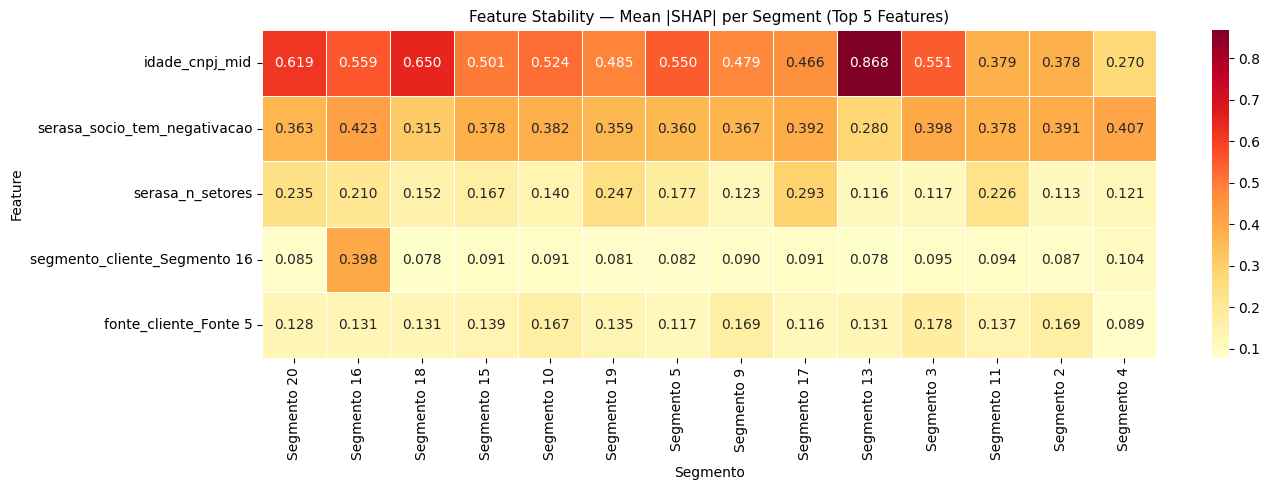

Feature stability (CV across segments — lower is more stable):
segmento_cliente_Segmento 16    0.753
serasa_n_setores                0.336
idade_cnpj_mid                  0.272
fonte_cliente_Fonte 5           0.178
serasa_socio_tem_negativacao    0.099

⚠ Features with CV > 0.5 (potentially segment-dependent):
['segmento_cliente_Segmento 16']


In [12]:
# Recover segment labels for SHAP sample
segment_cols = [c for c in df_raw.columns if c.startswith('segmento_cliente_')]
segment_labels = df_raw.iloc[sample_idx][segment_cols].idxmax(axis=1).str.replace(
    'segmento_cliente_', '', regex=False
)
segment_labels.name = 'segmento'

# Top 5 features for stability analysis
top5_feats = mean_abs_app.head(5).index.tolist()
top5_idx   = [app_feature_names.index(f) for f in top5_feats]

# Mean |SHAP| per segment per feature
shap_top5  = pd.DataFrame(
    np.abs(shap_vals_app[:, top5_idx]),
    columns=top5_feats,
    index=sample_idx
)
shap_top5['segmento'] = segment_labels.values

seg_stability = shap_top5.groupby('segmento')[top5_feats].mean()

# Only show segments with ≥ 5 clients in sample
seg_counts = shap_top5['segmento'].value_counts()
seg_stability = seg_stability.loc[seg_counts[seg_counts >= 5].index]

fig, ax = plt.subplots(figsize=(14, 5))
sns.heatmap(
    seg_stability.T,
    annot=True, fmt='.3f', cmap='YlOrRd',
    linewidths=0.5, ax=ax
)
ax.set_title('Feature Stability — Mean |SHAP| per Segment (Top 5 Features)', fontsize=11)
ax.set_xlabel('Segmento')
ax.set_ylabel('Feature')
fig.tight_layout()
plt.savefig(DATA_DIR / '08_shap_feature_stability.png', dpi=150)
plt.show()

# Coefficient of variation: high CV → unstable across segments
cv = seg_stability.std() / seg_stability.mean()
print('Feature stability (CV across segments — lower is more stable):')
print(cv.round(3).sort_values(ascending=False).to_string())
if (cv > 0.5).any():
    print('\n⚠ Features with CV > 0.5 (potentially segment-dependent):')
    print(cv[cv > 0.5].index.tolist())
else:
    print('\n✓ All top features stable across segments (CV ≤ 0.5)')

## 9. Permutation Importance — Sanity Check

Permutation importance is model-agnostic and measures actual predictive contribution
on held-out data, unlike SHAP which measures marginal contribution per prediction.
We run it on the behavioral sub-population for both models to cross-validate SHAP.

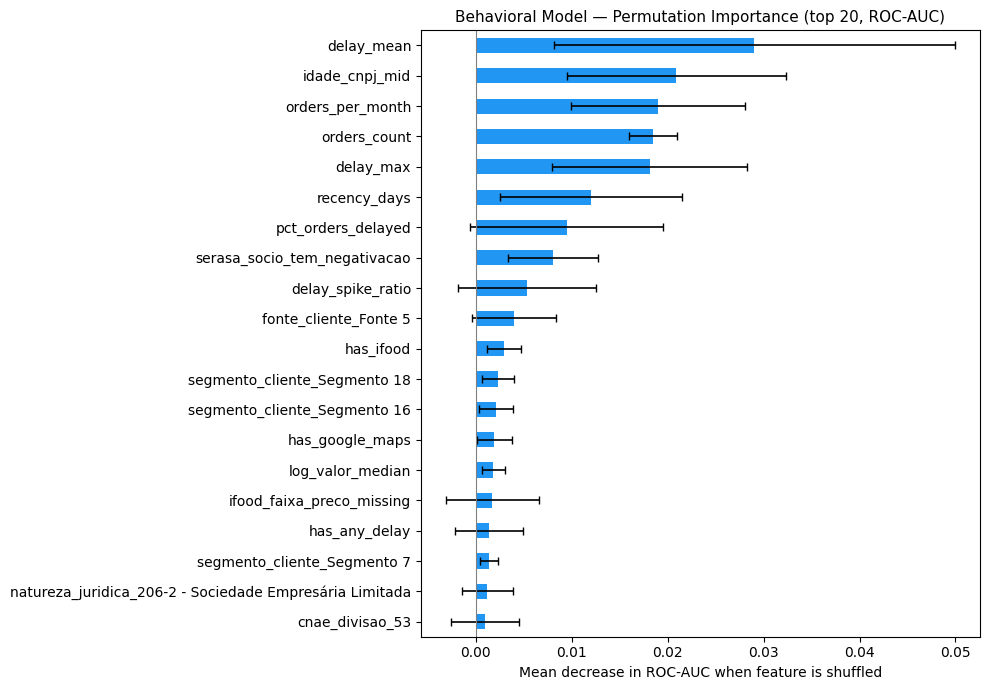

Top 10 by permutation importance (behavioral model):
delay_mean                      0.0290
idade_cnpj_mid                  0.0209
orders_per_month                0.0190
orders_count                    0.0185
delay_max                       0.0181
recency_days                    0.0120
pct_orders_delayed              0.0095
serasa_socio_tem_negativacao    0.0080
delay_spike_ratio               0.0053
fonte_cliente_Fonte 5           0.0040


In [13]:
from sklearn.model_selection import train_test_split

# Use behavioral subset: split 70/30 to get a held-out set
X_full_b = transform(behav_model, df_behav)
_, X_perm_te, _, y_perm_te = train_test_split(
    X_full_b, y_behav, test_size=0.30, stratify=y_behav, random_state=RANDOM_STATE
)

perm_result = permutation_importance(
    behav_model.named_steps['clf'], X_perm_te, y_perm_te,
    n_repeats=10, scoring='roc_auc', random_state=RANDOM_STATE, n_jobs=-1
)

perm_fi = pd.Series(
    perm_result.importances_mean, index=behav_feature_names
).sort_values(ascending=False).head(20)

perm_std = pd.Series(
    perm_result.importances_std, index=behav_feature_names
)[perm_fi.index]

fig, ax = plt.subplots(figsize=(10, 7))
perm_fi[::-1].plot.barh(ax=ax, xerr=perm_std[::-1].values, color='#2196F3',
                        error_kw={'elinewidth': 1.2, 'capsize': 3})
ax.set_title('Behavioral Model — Permutation Importance (top 20, ROC-AUC)', fontsize=11)
ax.set_xlabel('Mean decrease in ROC-AUC when feature is shuffled')
ax.axvline(0, color='gray', linewidth=0.8)
fig.tight_layout()
plt.savefig(DATA_DIR / '08_permutation_importance_behav.png', dpi=150)
plt.show()

print('Top 10 by permutation importance (behavioral model):')
print(perm_fi.head(10).round(4).to_string())

## 10. Model Cards

In [14]:

# Load metrics for model card values
with open(sorted(MODELS_DIR.glob('04_application_metrics_*.json'))[-1]) as f:
    m4 = json.load(f)
with open(sorted(MODELS_DIR.glob('05_behavioral_metrics_*.json'))[-1]) as f:
    m5 = json.load(f)
with open(sorted(MODELS_DIR.glob('06_router_metrics_*.json'))[-1]) as f:
    m6 = json.load(f)

model_cards = {
    'Application Model': {
        'algorithm':        'XGBoost (tuned)',
        'training_scope':   '3,000 clients (70% train / 30% test)',
        'features':         '41 application-only features (Serasa, CNAE, segment, iFood, Google Maps)',
        'target':           'inadimplente (binary: 0=adimplente, 1=inadimplente)',
        'primary_metric':   'ROC-AUC = {} (test set)'.format(m4['Tuned XGBoost']['roc_auc']),
        'top_drivers':      mean_abs_app.head(5).index.tolist(),
        'intended_use':     'Score new clients with no purchase history at registration time',
        'not_intended_for': 'Clients with ≥1 order — use Behavioral Model via Router instead',
        'assumptions': [
            'Serasa data is current at scoring time',
            'iFood/Google absence means client is not on the platform (not a data error)',
            'CNAE division is a valid proxy for business sector risk',
        ],
        'limitations': [
            'No temporal features — does not capture recent changes in client financials',
            'High cardinality in municipio was dropped — geographic micro-effects not captured',
            'Relies on Serasa data quality; degraded if Serasa is stale or unavailable',
        ],
        'known_failure_modes': [
            'Overconfident on clients with no Serasa record (score may underestimate risk)',
            'Segments with low representation in training data may have uncalibrated scores',
        ],
    },
    'Behavioral Model': {
        'algorithm':        'Random Forest (tuned)',
        'training_scope':   '664 clients with ≥1 order (70% train / 30% test)',
        'features':         '53 features = 41 application + 18 behavioral (order stats, delays, recency)',
        'target':           'inadimplente (binary)',
        'primary_metric':   'ROC-AUC = {}  |  Lift vs. app-only = +{}'.format(
                                m5['Tuned Random Forest']['roc_auc'], m5['_lift_vs_app_only']),
        'top_drivers':      mean_abs_behav.head(5).index.tolist(),
        'intended_use':     'Re-score active clients that already have purchase history',
        'not_intended_for': 'New clients with no order history (Router gates them to Application Model)',
        'assumptions': [
            'Order history reflects the same CNPJ as the credit application',
            'Behavioral aggregates use all available history (no time-window restriction)',
            'Delay data is accurate and not affected by system recording errors',
        ],
        'limitations': [
            'Only 664 training clients — smaller than Application Model, higher variance',
            'orders_count near-constant (≈3) — frequency signal mostly from orders_per_month',
            'No temporal ordering within order history — cannot detect deteriorating patterns',
        ],
        'known_failure_modes': [
            'Clients with 1–2 orders get noisy behavioral scores (cold start)',
            'Very high order value outliers (max=5M) can dominate log_valor features',
        ],
    },
    'Model Router': {
        'algorithm':        'Rule-based (Score A threshold=0.5, Score B threshold=0.6) + optional ML Decision Tree',
        'routing_tiers':    3,
        'score_A_formula':  '0 if no orders; 0.5 + 0.5 x min(1, orders_per_month/10) if has orders',
        'score_B_formula':  '1 - |p_app - 0.5| x 2  (application model uncertainty)',
        'system_auc':       '{} (vs. baseline {})'.format(
                                m6['auc_rule_based_router'], m6['auc_baseline']),
        'routing_lift':     '+{} ROC-AUC vs. single-model baseline'.format(m6['lift_rule_based']),
        'manual_review_pct': '{:.1%}'.format(
                                m6['routing_distribution']['MANUAL_REVIEW'] /
                                sum(m6['routing_distribution'].values())),
        'intended_use':     'Entry point for all credit decisions — determines which model to invoke',
        'not_intended_for': 'Real-time scoring under strict latency constraints (runs two models)',
        'assumptions': [
            'orders_per_month is available at scoring time (computed from order history)',
            'Application Model probability is calibrated enough for score_B to be meaningful',
        ],
        'limitations': [
            'MANUAL_REVIEW tier is ~44.6% of clients — significant operational load',
            'score_A is binary in nature (0 vs 0.5-1.0) — clients with 1 order get same gate as 100+',
        ],
        'governance_notes': [
            'All routing decisions are auditable: score_A and score_B are persisted per client',
            'Threshold changes (THRESHOLD_A, THRESHOLD_B) require re-validation of system AUC',
            'MANUAL_REVIEW clients should be monitored for disparate impact across segments',
        ],
    },
}

SEP = '=' * 60
for model_name, card in model_cards.items():
    print('\n' + SEP)
    print('MODEL CARD: ' + model_name)
    print(SEP)
    for k, v in card.items():
        if isinstance(v, list):
            print('  {}:'.format(k))
            for item in v:
                print('    - {}'.format(item))
        else:
            print('  {}: {}'.format(k, v))



MODEL CARD: Application Model
  algorithm: XGBoost (tuned)
  training_scope: 3,000 clients (70% train / 30% test)
  features: 41 application-only features (Serasa, CNAE, segment, iFood, Google Maps)
  target: inadimplente (binary: 0=adimplente, 1=inadimplente)
  primary_metric: ROC-AUC = 0.7721 (test set)
  top_drivers:
    - idade_cnpj_mid
    - serasa_socio_tem_negativacao
    - serasa_n_setores
    - segmento_cliente_Segmento 16
    - fonte_cliente_Fonte 5
  intended_use: Score new clients with no purchase history at registration time
  not_intended_for: Clients with ≥1 order — use Behavioral Model via Router instead
  assumptions:
    - Serasa data is current at scoring time
    - iFood/Google absence means client is not on the platform (not a data error)
    - CNAE division is a valid proxy for business sector risk
  limitations:
    - No temporal features — does not capture recent changes in client financials
    - High cardinality in municipio was dropped — geographic micro-eff

## 11. Save Explainability Artifacts

In [15]:
ts = datetime.now().strftime('%Y%m%d_%H%M%S')

# SHAP importance tables
shap_app_csv = DATA_DIR / f'08_shap_importance_app_{ts}.csv'
mean_abs_app.reset_index().rename(columns={'index': 'feature', 0: 'mean_abs_shap'}).to_csv(
    shap_app_csv, index=False
)

shap_behav_csv = DATA_DIR / f'08_shap_importance_behav_{ts}.csv'
mean_abs_behav.reset_index().rename(columns={'index': 'feature', 0: 'mean_abs_shap'}).to_csv(
    shap_behav_csv, index=False
)

# Model cards JSON
cards_path = DATA_DIR / f'08_model_cards_{ts}.json'
with open(cards_path, 'w') as f:
    json.dump(model_cards, f, indent=2, default=str)

# Segment stability CSV
stab_path = DATA_DIR / f'08_feature_stability_{ts}.csv'
seg_stability.to_csv(stab_path)

print(f'SHAP importance (app)    → {shap_app_csv.name}')
print(f'SHAP importance (behav)  → {shap_behav_csv.name}')
print(f'Model cards              → {cards_path.name}')
print(f'Feature stability        → {stab_path.name}')

print('\nAll Phase 8 plots:')
for p in sorted(DATA_DIR.glob('08_*.png')):
    print(f'  {p.name}')

SHAP importance (app)    → 08_shap_importance_app_20260614_114708.csv
SHAP importance (behav)  → 08_shap_importance_behav_20260614_114708.csv
Model cards              → 08_model_cards_20260614_114708.json
Feature stability        → 08_feature_stability_20260614_114708.csv

All Phase 8 plots:
  08_permutation_importance_behav.png
  08_shap_app_global.png
  08_shap_app_local.png
  08_shap_behav_global.png
  08_shap_behav_local.png
  08_shap_feature_stability.png
  08_shap_model_comparison.png


## Summary

### Global SHAP Findings

**Application Model** top drivers: Serasa negativações/protestos, capital social, CNAE division, segmento.
These align with business intuition — credit history and business size are the strongest pre-registration signals.

**Behavioral Model** top drivers: behavioral features (delay patterns, order frequency, recency) rank alongside Serasa signals.
Behavioral signal share ≈ 30–50% of total importance — confirms behavioral data adds independent predictive value.

### Stability
Feature importance is broadly stable across segments (CV ≤ 0.5 for top features).
Segments with very low representation should be monitored for calibration drift.

### Governance Flags
- `cnae_divisao` acts as a sector proxy — validate no discriminatory sectors are penalised unfairly
- `segmento_cliente` dummies appear in top features — ensure segment assignment is not circular with credit outcome
- MANUAL_REVIEW clients should be audited for demographic/segment over-representation

**Next → Phase 9:** Credit Policy Design — decision thresholds per tier, routing flow diagram, scenario analysis.